# Clustering de riesgo ambiental

Este notebook aplica K-Means para identificar perfiles de riesgo ambiental a partir de contaminantes, condiciones meteorológicas, vulnerabilidad respiratoria y contexto industrial.

In [38]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def encontrar_raiz_proyecto() -> Path:
    #Localiza la raíz del repositorio sin depender de la carpeta desde la que se inició Jupyter.
    
    actual = Path.cwd().resolve()

    for candidato in (actual, *actual.parents):
        if (
            (candidato / "docker-compose.yml").is_file()
            and (candidato / "src").is_dir()
            and (candidato / "notebooks").is_dir()
        ):
            return candidato

    raise FileNotFoundError(
        "No fue posible encontrar la raíz del proyecto. "
        "Abre el notebook desde el repositorio."
    )


PROJECT_ROOT = encontrar_raiz_proyecto()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.preprocessing import (
    cargar_dataset_desde_api,
    limpiar_dataset,
)

from src.clustering import (
    agregar_clusters,
    asignar_etiquetas_riesgo,
    entrenar_kmeans,
    escalar_variables,
    evaluar_numero_clusters,
    obtener_centroides,
    resumir_clusters,
)

from src.visualizations import (
    graficar_clusters,
)


print(f"Raíz del proyecto: {PROJECT_ROOT}")
print("Importaciones correctas")

Raíz del proyecto: C:\Users\yvl\Documents\GitHub\air-quality-monitoring-platform
Importaciones correctas


## Carga del dataset

El notebook utiliza primero el archivo procesado local. Si el archivo no está disponible, descarga los datos desde la API.

In [39]:
API_DATASET_URL = (
    "http://localhost:8000"
    "/analytics/dataset-modelado"
)

df_original = cargar_dataset_desde_api(
    api_url=API_DATASET_URL,
    limit=1000,
    timeout=60,
)

columnas_esperadas = [
    "fecha_hora",
    "comuna",
    "region",
    "codigo_estacion",
    "tipo_sensor",
    "mp25",
    "mp10",
    "so2",
    "no2",
    "velocidad_viento",
    "direccion_viento_grados",
    "temperatura",
    "humedad",
    "indice_vulnerabilidad_respiratoria",
    "emision_maxima_permitida",
    "categoria_ica",
]

columnas_faltantes = [
    columna
    for columna in columnas_esperadas
    if columna not in df_original.columns
]

if df_original.empty:
    raise ValueError(
        "La API devolvió un dataset vacío."
    )

if columnas_faltantes:
    raise ValueError(
        "Faltan columnas requeridas: "
        + ", ".join(columnas_faltantes)
    )

df = limpiar_dataset(df_original)

print("Fuente: API paginada con datos integrados por el ETL")
print(f"Filas obtenidas: {len(df_original)}")
print(f"Filas procesadas: {len(df)}")
print(f"Columnas procesadas: {len(df.columns)}")
print(f"Fecha inicial: {df['fecha_hora'].min()}")
print(f"Fecha final: {df['fecha_hora'].max()}")

df.head()

Registros descargados: 1000
Registros descargados: 2000
Registros descargados: 3000
Registros descargados: 4000
Registros descargados: 5000
Registros descargados: 6000
Registros descargados: 7000
Registros descargados: 8000
Registros descargados: 9000
Registros descargados: 10000
Registros descargados: 11000
Registros descargados: 12000
Registros descargados: 13000
Registros descargados: 14000
Registros descargados: 15000
Registros descargados: 16000
Registros descargados: 17000
Registros descargados: 18000
Registros descargados: 19000
Registros descargados: 20000
Registros descargados: 21000
Registros descargados: 22000
Registros descargados: 23000
Registros descargados: 24000
Registros descargados: 25000
Registros descargados: 26000
Registros descargados: 26693
Fuente: API paginada con datos integrados por el ETL
Filas obtenidas: 26693
Filas procesadas: 26622
Columnas procesadas: 22
Fecha inicial: 2026-01-06 00:00:00
Fecha final: 2026-12-09 00:00:00


,fecha_hora,comuna,region,codigo_estacion,tipo_sensor,mp25,mp10,so2,no2,velocidad_viento,...,humedad,indice_vulnerabilidad_respiratoria,emision_maxima_permitida,categoria_ica,fecha,anio,mes,dia,hora,dia_semana
0,2026-01-06 00:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,52.4,88.1,17.3,31.0,1.2,...,88.0,61.5,320.0,Regular,2026-01-06,2026,1,6,0,Tuesday
1,2026-01-06 06:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,49.8,84.4,16.8,29.6,1.5,...,91.0,61.5,320.0,Buena,2026-01-06,2026,1,6,6,Tuesday
2,2026-01-06 12:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,28.5,54.2,14.1,24.7,4.6,...,61.0,61.5,320.0,Buena,2026-01-06,2026,1,6,12,Tuesday
3,2026-01-06 18:00:00,Rancagua,O'Higgins,SEN-RAN-OF-001,publico_oficial,45.2,76.3,15.9,28.3,2.8,...,74.0,61.5,320.0,Buena,2026-01-06,2026,1,6,18,Tuesday
4,2026-02-06 00:00:00,Talca,Maule,SEN-TAL-OF-001,publico_oficial,61.7,97.5,13.6,27.4,1.0,...,92.0,64.2,420.0,Regular,2026-02-06,2026,2,6,0,Friday


## Selección de variables

MP10 no se incluye porque presenta una correlación de 0.98 con MP2.5. Entre temperatura, humedad y velocidad del viento se selecciona únicamente la velocidad del viento, debido a la alta correlación existente entre estas variables meteorológicas.

Las variables seleccionadas representan:

- contaminación por material particulado;
- contaminación por gases;
- capacidad de dispersión atmosférica;
- vulnerabilidad respiratoria;
- contexto de emisiones industriales.

In [40]:
variables_propuestas = [
    "mp25",
    "so2",
    "no2",
    "velocidad_viento",
    "indice_vulnerabilidad_respiratoria",
    "emision_maxima_permitida",
]

variables_clustering = [
    variable
    for variable in variables_propuestas
    if variable in df.columns
]

variables_faltantes = [
    variable
    for variable in variables_propuestas
    if variable not in df.columns
]

print("Variables utilizadas para K-Means:")

for variable in variables_clustering:
    print(f"- {variable}")

if variables_faltantes:
    print("\nVariables no disponibles:")

    for variable in variables_faltantes:
        print(f"- {variable}")

if len(variables_clustering) < 2:
    raise ValueError(
        "No existen suficientes variables para clustering."
    )

Variables utilizadas para K-Means:
- mp25
- so2
- no2
- velocidad_viento
- indice_vulnerabilidad_respiratoria
- emision_maxima_permitida


Celda de diagnostico

In [41]:
diagnostico_variables = pd.DataFrame(
    {
        "variable": variables_clustering,
        "tipo": [
            str(df[variable].dtype)
            for variable in variables_clustering
        ],
        "nulos": [
            int(df[variable].isna().sum())
            for variable in variables_clustering
        ],
        "porcentaje_nulos": [
            round(
                df[variable].isna().mean() * 100,
                2,
            )
            for variable in variables_clustering
        ],
        "valores_unicos": [
            int(
                df[variable].nunique(
                    dropna=True
                )
            )
            for variable in variables_clustering
        ],
    }
)

display(diagnostico_variables)

,variable,tipo,nulos,porcentaje_nulos,valores_unicos
0,mp25,float64,0,0.00,1195
1,so2,float64,0,0.00,91
2,no2,float64,0,0.00,79
3,velocidad_viento,float64,0,0.00,133
4,indice_vulnerabilidad_respiratoria,float64,0,0.00,27
5,emision_maxima_permitida,float64,2086,7.84,24


## Preparación y estandarización

Los valores nulos se imputan mediante la mediana de cada variable. Posteriormente, las variables se estandarizan con `StandardScaler`, evitando que las diferencias de escala dominen el resultado de K-Means.

In [42]:
(
    X_scaled,
    scaler,
    datos_modelo,
    columnas_utilizadas,
) = escalar_variables(
    df,
    columnas=variables_clustering,
)

print(f"Registros preparados: {X_scaled.shape[0]}")
print(f"Variables utilizadas: {X_scaled.shape[1]}")
print(f"Nulos restantes: {datos_modelo.isna().sum().sum()}")
print(f"Columnas finales: {columnas_utilizadas}")

display(
    datos_modelo
    .describe()
    .transpose()
    .round(3)
)

Registros preparados: 26622
Variables utilizadas: 6
Nulos restantes: 0
Columnas finales: ['mp25', 'so2', 'no2', 'velocidad_viento', 'indice_vulnerabilidad_respiratoria', 'emision_maxima_permitida']


,count,mean,std,min,25%,50%,75%,max
mp25,26622.0,45.613,23.451,9.00,29.90,37.40,60.75,178.05
so2,26622.0,30.922,14.505,10.70,19.00,25.00,41.00,310.00
no2,26622.0,48.159,12.421,20.80,39.00,45.00,58.00,86.00
velocidad_viento,26622.0,3.161,1.608,0.35,1.86,2.69,4.55,6.37
indice_vulnerabilidad_respiratoria,26622.0,67.370,5.335,54.80,63.20,67.80,72.70,76.20
emision_maxima_permitida,26622.0,294.244,159.538,90.00,155.00,260.00,420.00,650.00


## Evaluación del número de clusters

Se comparan valores de K entre 2 y 6 mediante:

- **Inercia:** mide la compactación interna de los grupos.
- **Silhouette:** mide la separación entre los clusters; valores más altos
  representan una mejor separación.

Celda de evaluación

In [43]:
evaluacion = evaluar_numero_clusters(
    X_scaled,
    min_clusters=2,
    max_clusters=6,
    random_state=42,
    max_muestra_silhouette=5000,
)

display(
    evaluacion.round(
        {
            "inercia": 2,
            "silhouette": 4,
        }
    )
)

,n_clusters,inercia,silhouette
0,2,106261.27,0.3241
1,3,83926.53,0.2813
2,4,71554.02,0.2686
3,5,63276.73,0.2606
4,6,56432.11,0.2733


# Gráfico del método del codo

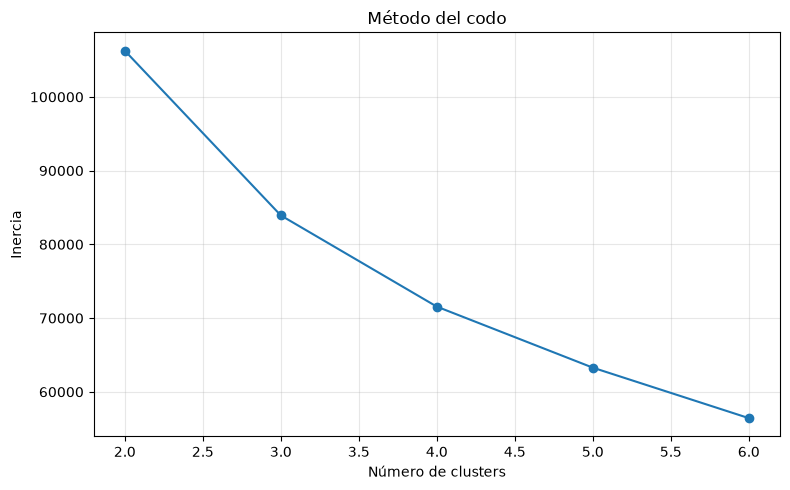

In [44]:
figura, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    evaluacion["n_clusters"],
    evaluacion["inercia"],
    marker="o",
)

ax.set_title("Método del codo")
ax.set_xlabel("Número de clusters")
ax.set_ylabel("Inercia")
ax.grid(alpha=0.3)

figura.tight_layout()
plt.show()

# Gráfico de silhouette

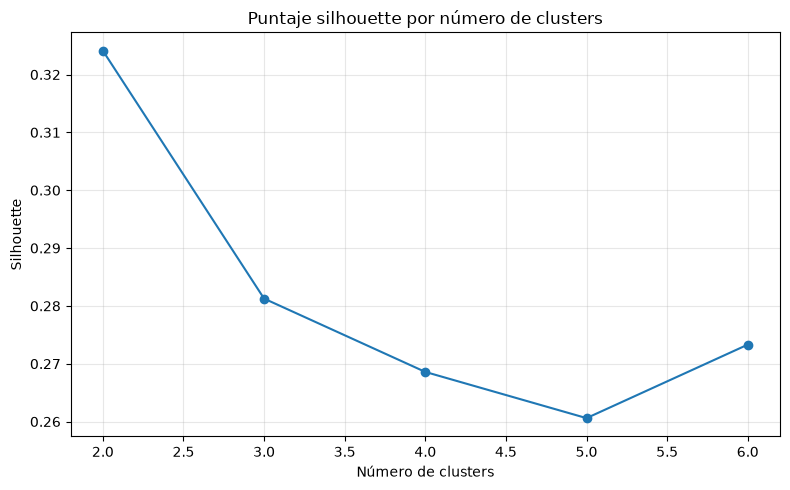

In [45]:
figura, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    evaluacion["n_clusters"],
    evaluacion["silhouette"],
    marker="o",
)

ax.set_title("Puntaje silhouette por número de clusters")
ax.set_xlabel("Número de clusters")
ax.set_ylabel("Silhouette")
ax.grid(alpha=0.3)

figura.tight_layout()
plt.show()

In [46]:
display(evaluacion)

,n_clusters,inercia,silhouette
0,2,106261.267978,0.324122
1,3,83926.528090,0.281261
2,4,71554.024117,0.268582
3,5,63276.734233,0.260595
4,6,56432.110604,0.273304


## Selección final del número de clusters

El mayor puntaje silhouette se obtuvo con K=2, alcanzando aproximadamente
0.3242. Sin embargo, se selecciona K=3 para construir tres perfiles
interpretables de riesgo ambiental:

- Bajo riesgo.
- Riesgo moderado.
- Riesgo crítico.

La elección representa un equilibrio entre separación estadística e
interpretabilidad funcional. K=3 presenta un silhouette aproximado de 0.2813,
por lo que genera una separación menor que K=2, pero permite cumplir el
objetivo analítico del proyecto.

In [47]:
K_FINAL = 3

resultado_k_final = evaluacion.loc[
    evaluacion["n_clusters"] == K_FINAL
].iloc[0]

silhouette_final = float(
    resultado_k_final["silhouette"]
)

inercia_final = float(
    resultado_k_final["inercia"]
)

print(f"K seleccionado: {K_FINAL}")
print(f"Inercia: {inercia_final:.2f}")
print(f"Silhouette: {silhouette_final:.4f}")

K seleccionado: 3
Inercia: 83926.53
Silhouette: 0.2813


In [48]:
modelo_kmeans = entrenar_kmeans(
    X_scaled,
    n_clusters=K_FINAL,
    random_state=42,
)

df_clusterizado = agregar_clusters(
    df,
    modelo_kmeans,
    X_scaled,
)

print("Modelo K-Means entrenado correctamente.")
print(
    f"Clusters encontrados: "
    f"{df_clusterizado['cluster'].nunique()}"
)

display(
    df_clusterizado[
        [
            "fecha_hora",
            "region",
            "comuna",
            "mp25",
            "cluster",
        ]
    ].head()
)

Modelo K-Means entrenado correctamente.
Clusters encontrados: 3


,fecha_hora,region,comuna,mp25,cluster
0,2026-01-06 00:00:00,O'Higgins,Rancagua,52.4,2
1,2026-01-06 06:00:00,O'Higgins,Rancagua,49.8,2
2,2026-01-06 12:00:00,O'Higgins,Rancagua,28.5,1
3,2026-01-06 18:00:00,O'Higgins,Rancagua,45.2,1
4,2026-02-06 00:00:00,Maule,Talca,61.7,2


In [49]:
modelo_kmeans = entrenar_kmeans(
    X_scaled,
    n_clusters=K_FINAL,
    random_state=42,
)

df_clusterizado = agregar_clusters(
    df,
    modelo_kmeans,
    X_scaled,
)

print("Modelo K-Means entrenado correctamente.")
print(
    f"Clusters encontrados: "
    f"{df_clusterizado['cluster'].nunique()}"
)

display(
    df_clusterizado[
        [
            "fecha_hora",
            "region",
            "comuna",
            "mp25",
            "cluster",
        ]
    ].head()
)

Modelo K-Means entrenado correctamente.
Clusters encontrados: 3


,fecha_hora,region,comuna,mp25,cluster
0,2026-01-06 00:00:00,O'Higgins,Rancagua,52.4,2
1,2026-01-06 06:00:00,O'Higgins,Rancagua,49.8,2
2,2026-01-06 12:00:00,O'Higgins,Rancagua,28.5,1
3,2026-01-06 18:00:00,O'Higgins,Rancagua,45.2,1
4,2026-02-06 00:00:00,Maule,Talca,61.7,2


In [50]:
datos_para_perfil = datos_modelo.copy()

datos_para_perfil["cluster"] = (
    modelo_kmeans.labels_
)

datos_para_perfil = asignar_etiquetas_riesgo(
    datos_para_perfil,
)

df_clusterizado["nivel_riesgo"] = (
    datos_para_perfil["nivel_riesgo"]
    .to_numpy()
)

print("Etiquetas asignadas:")

for etiqueta in sorted(
    df_clusterizado["nivel_riesgo"].unique()
):
    print(f"- {etiqueta}")

Etiquetas asignadas:
- Bajo riesgo
- Riesgo crítico
- Riesgo moderado


In [51]:
perfil_clusters = resumir_clusters(
    datos_para_perfil
)

display(
    perfil_clusters.round(3)
)

,cluster,nivel_riesgo,cantidad_registros,puntaje_riesgo,mp25,so2,no2,indice_vulnerabilidad_respiratoria,emision_maxima_permitida,velocidad_viento
0,1,Bajo riesgo,13175,0.000,32.143,21.954,41.352,65.612,214.567,3.895
1,0,Riesgo moderado,7010,0.568,44.201,50.883,62.913,71.304,493.839,3.175
2,2,Riesgo crítico,6437,0.678,74.723,27.539,46.023,66.684,239.962,1.645


In [52]:
centroides = obtener_centroides(
    modelo_kmeans,
    scaler,
    columnas_utilizadas,
)

centroides_interpretados = centroides.merge(
    perfil_clusters[
        [
            "cluster",
            "nivel_riesgo",
            "cantidad_registros",
            "puntaje_riesgo",
        ]
    ],
    on="cluster",
    how="left",
)

columnas_iniciales = [
    "cluster",
    "nivel_riesgo",
    "cantidad_registros",
    "puntaje_riesgo",
]

columnas_restantes = [
    columna
    for columna in centroides_interpretados.columns
    if columna not in columnas_iniciales
]

centroides_interpretados = centroides_interpretados[
    columnas_iniciales + columnas_restantes
]

display(
    centroides_interpretados.round(3)
)

,cluster,nivel_riesgo,cantidad_registros,puntaje_riesgo,mp25,so2,no2,velocidad_viento,indice_vulnerabilidad_respiratoria,emision_maxima_permitida
0,0,Riesgo moderado,7010,0.568,44.185,50.868,62.890,3.177,71.302,493.771
1,1,Bajo riesgo,13175,0.000,32.143,21.946,41.352,3.894,65.608,214.471
2,2,Riesgo crítico,6437,0.678,74.735,27.531,46.020,1.646,66.687,239.849


In [53]:
orden_riesgo = [
    "Bajo riesgo",
    "Riesgo moderado",
    "Riesgo crítico",
]

distribucion_riesgo = (
    df_clusterizado["nivel_riesgo"]
    .value_counts()
    .reindex(orden_riesgo)
    .fillna(0)
    .astype(int)
    .rename_axis("nivel_riesgo")
    .reset_index(name="cantidad_registros")
)

distribucion_riesgo["porcentaje"] = (
    distribucion_riesgo["cantidad_registros"]
    / len(df_clusterizado)
    * 100
).round(2)

display(distribucion_riesgo)

,nivel_riesgo,cantidad_registros,porcentaje
0,Bajo riesgo,13175,49.49
1,Riesgo moderado,7010,26.33
2,Riesgo crítico,6437,24.18


## Visualización de los perfiles de riesgo

La siguiente visualización proyecta los clusters utilizando MP2.5 y el índice
de vulnerabilidad respiratoria. Aunque el modelo fue entrenado con más
variables, esta vista bidimensional facilita la interpretación de los grupos.

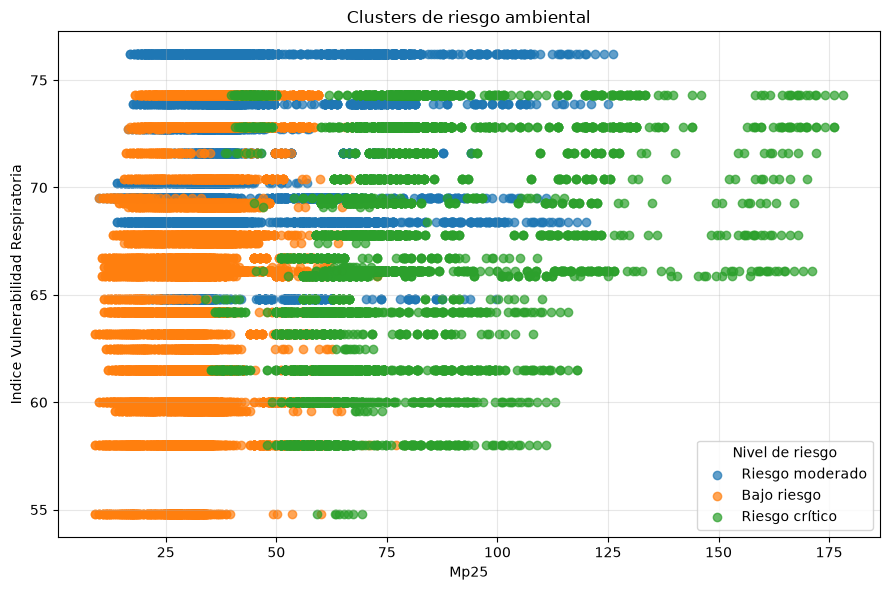

In [54]:
figura, ax = graficar_clusters(
    df_clusterizado,
    variable_x="mp25",
    variable_y="indice_vulnerabilidad_respiratoria",
    columna_cluster="cluster",
    columna_etiqueta="nivel_riesgo",
)

plt.show()

In [55]:
riesgo_por_comuna = (
    df_clusterizado.assign(
        es_riesgo_critico=(
            df_clusterizado["nivel_riesgo"]
            == "Riesgo crítico"
        )
    )
    .groupby(
        ["region", "comuna"],
        as_index=False,
    )
    .agg(
        cantidad_mediciones=(
            "mp25",
            "count",
        ),
        mp25_promedio=(
            "mp25",
            "mean",
        ),
        mp25_maximo=(
            "mp25",
            "max",
        ),
        proporcion_critica=(
            "es_riesgo_critico",
            "mean",
        ),
    )
)

riesgo_por_comuna["porcentaje_critico"] = (
    riesgo_por_comuna["proporcion_critica"]
    * 100
).round(2)

riesgo_por_comuna = (
    riesgo_por_comuna
    .drop(columns="proporcion_critica")
    .sort_values(
        [
            "porcentaje_critico",
            "mp25_promedio",
        ],
        ascending=False,
    )
)

display(
    riesgo_por_comuna
    .head(10)
    .round(2)
)

,region,comuna,cantidad_mediciones,mp25_promedio,mp25_maximo,porcentaje_critico
20,O'Higgins,Rancagua,2140,45.91,118.05,43.04
24,Ñuble,Chillán,2139,57.36,176.05,42.36
26,Ñuble,San Carlos,1411,53.40,171.05,38.70
14,Maule,Linares,1347,50.98,168.05,38.08
16,Maule,Parral,674,52.96,170.05,37.69
5,Biobío,Los Ángeles,1766,53.57,178.05,37.15
1,Biobío,Cabrero,674,50.45,167.05,36.80
18,Maule,Talca,1769,41.64,116.05,33.80
11,Maule,Cauquenes,675,44.17,157.05,32.15
7,Biobío,Nacimiento,674,53.56,172.05,29.67


In [56]:
niveles_esperados = {
    "Bajo riesgo",
    "Riesgo moderado",
    "Riesgo crítico",
}

niveles_obtenidos = set(
    df_clusterizado["nivel_riesgo"]
    .dropna()
    .unique()
)

assert len(df_clusterizado) == len(df)
assert df_clusterizado["cluster"].nunique() == K_FINAL
assert df_clusterizado["nivel_riesgo"].notna().all()
assert niveles_obtenidos == niveles_esperados

print("Validación del clustering completada correctamente.")

Validación del clustering completada correctamente.


## Conclusiones del clustering

Se evaluaron configuraciones de K-Means entre 2 y 6 clusters mediante inercia y puntaje silhouette.

El mayor silhouette se obtuvo con **K=2**, alcanzando aproximadamente **0.3242**. Sin embargo, se seleccionó **K=3**, con un silhouette de aproximadamente **0.2813**, para construir tres perfiles interpretables de riesgo ambiental: bajo, moderado y crítico.

Esta decisión representa un equilibrio entre separación estadística e interpretabilidad funcional.

### Perfil de bajo riesgo

El perfil de bajo riesgo contiene **13.175 registros**, equivalentes al **49,49%** del dataset analizado.

Este grupo presenta un MP2.5 promedio cercano a **32,14**, el menor entre los tres clusters. En términos relativos, representa condiciones ambientales menos desfavorables dentro del conjunto de datos.

### Perfil de riesgo moderado

El perfil de riesgo moderado contiene **7.010 registros**, equivalentes al **26,33%** del dataset.

Su MP2.5 promedio es cercano a **44,20**. Este cluster también presenta valores elevados de contaminantes gaseosos como SO2 y NO2 en comparación con los otros perfiles, lo que refleja una combinación ambiental distinta y no solamente un nivel intermedio de material particulado.

### Perfil de riesgo crítico

El perfil de riesgo crítico contiene **6.437 registros**, equivalentes al **24,18%** del dataset.

Este grupo presenta un MP2.5 promedio cercano a **74,72**, considerablemente mayor que los promedios de los otros clusters. Su clasificación se explica por la combinación ponderada de contaminación, ventilación, vulnerabilidad respiratoria y contexto industrial.

### Distribución territorial del riesgo crítico

Las comunas con mayor proporción de registros clasificados como riesgo crítico son:

1. **Rancagua**, con **43,04%**.
2. **Chillán**, con **42,36%**.
3. **San Carlos**, con **38,70%**.
4. **Linares**, con **38,08%**.
5. **Parral**, con **37,69%**.
6. **Los Ángeles**, con **37,15%**.
7. **Cabrero**, con **36,80%**.
8. **Talca**, con **33,80%**.
9. **Cauquenes**, con **32,15%**.
10. **Nacimiento**, con **29,67%**.

Estos resultados permiten identificar territorios donde aparece una mayor frecuencia relativa de condiciones ambientales clasificadas como críticas.

### Interpretación del modelo

Los clusters representan perfiles relativos dentro del dataset. La categoría de riesgo crítico no implica que todas sus variables sean mayores que las de los demás grupos, sino que su combinación produce el puntaje de riesgo relativo más alto según la ponderación utilizada.

En particular, el grupo moderado presenta mayores valores promedio de algunos contaminantes gaseosos, mientras que el grupo crítico se caracteriza principalmente por niveles considerablemente más altos de MP2.5.

### Limitaciones

Las fuentes utilizadas corresponden a un caso académico con datos simulados. Las categorías obtenidas no representan una clasificación regulatoria oficial ni deben interpretarse como evidencia de causalidad.

Además, K-Means forma grupos según distancia matemática y supone clusters aproximadamente compactos. La selección de variables, su escalamiento y la ponderación utilizada para interpretar los grupos influyen directamente en los resultados.

### Aporte al proyecto

El clustering transforma miles de registros ambientales en tres perfiles comprensibles. Esto facilita:

* identificar condiciones de mayor riesgo relativo;
* priorizar comunas para análisis posterior;
* alimentar visualizaciones del dashboard;
* resumir patrones multivariables;
* apoyar la toma de decisiones dentro del caso de estudio.
